In [ ]:
from collections import defaultdict
import json
from torch.utils.data import Dataset, DataLoader
import os, sys, torch, random
from pathlib import Path
import numpy as np
from torchvision import tv_tensors                                      
from utils.utils import (
    crop_ultrasound_pil,
    extract_bbox_ultrasound_cv2,
    organ_to_class_dict,
    dataset_to_organ_dict,
    dataset_for_classification,
    dataset_for_segmentation,
    multi_cls_labels_dict,
    resize_pad,
)
from PIL import Image
from torchvision.transforms.v2.functional import pil_to_tensor, center_crop, to_pil_image
from transformers import AutoImageProcessor, AutoModel
from transformers.image_utils import load_image
from tqdm import tqdm 
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
import numpy as np
from data_classes.datasets import USdatasetOmni

In [ ]:
from utils.utils import get_sft_transforms
from utils.paths import *


dataset = USdatasetOmni(
    base_dir=DATA_DIR,
    split="val_cls",
    transforms=get_sft_transforms(train=False),
    out_size=1024,
    data_type="segmentation",
    ccl_crop=False,
    keep_aspect_ratio=True,
    self_norm=True, 
    skip_dataset="Testicle",
    id_dropout=0.0
)
len(dataset)

In [ ]:
from argparse import Namespace
from collections import defaultdict
from copy import deepcopy
from transformers.trainer import Trainer
from transformers.training_args import TrainingArguments
from data_classes.datasets import USdatasetOmni
from torchvision.transforms import InterpolationMode, v2
import torch, wandb, random
from sklearn.metrics import accuracy_score
from nets.cls_net import OmniClsCBAM
from nets.segm_net import UNet2DFiLM, MedSAM, MedSAMPrompt
from utils.paths import DATA_DIR
from utils.utils import organ_to_class_dict, multi_cls_labels_dict, generate_run_hash
import numpy as np
from utils.utils import (
    get_sft_transforms,
    compute_dsc,
    class_to_organ_dict,
    compute_nsd,
    mask_overlap_visualization,
)
from utils.stratified_splits import build_train_val_datasets
from utils.paths import *
from torch.utils.data import Subset, ConcatDataset


In [ ]:
from segment_anything import sam_model_registry
sam_model = sam_model_registry["vit_b"](checkpoint=MEDSAM_BASE_WEIGHTS)
print(sum([p.numel() for p in sam_model.parameters()]))
model = MedSAMPrompt(
            image_encoder=deepcopy(sam_model.image_encoder),
            mask_decoder=deepcopy(sam_model.mask_decoder),
            prompt_encoder=deepcopy(sam_model.prompt_encoder),
            predict_bboxes=True,
            freeze_image_encoder=0,
        )
model.cuda()

In [ ]:
training_args = TrainingArguments(
    output_dir="./loggings/debug",
    # num_train_epochs=args.epochs,
    max_steps=1,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    logging_dir="./logs",
    seed=42,
    save_strategy="steps",
    eval_strategy="steps",
    save_steps=int(1 / 100),
    eval_steps=int(1 / 100),
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    save_total_limit=2,
    report_to=None,
    dataloader_num_workers=8,
    logging_steps=10,
    log_level="info",
    eval_accumulation_steps=100,
    optim="adamw_torch",
    learning_rate=1e-3,
    weight_decay=0.01,
    lr_scheduler_type="cosine",
    warmup_ratio=0.06,
    max_grad_norm=1.0,
    gradient_accumulation_steps=2,
    # fp16=True,
    # push_to_hub=False,
)

In [ ]:
from safetensors.torch import load_file
# from utils.distill_enc import apply_lora_to_encoder
# peft_model_dict = torch.load("/media/raid0/US_FiLMUNet/loggings/peft_unet4_2/final_model_lora.pth")
model = UNet2DFiLM(
    in_channels=3,
    num_classes=1,
    # n_organs=len(organ_to_class_dict),
    n_organs=8,
    size=32,
    depth=5,
    film_start=0,
    use_film=True,
    distill=True
)
state_dict = load_file("/media/raid0/US_FiLMUNet/checkpoints/unet5/model.safetensors")
model.load_state_dict(state_dict, strict=False)

model.cuda()

In [ ]:
from train.segm_train import UNet2DFiLM
model = UNet2DFiLM(
    in_channels=3,
    num_classes=1,
    # n_organs=len(organ_to_class_dict),
    n_organs=8,
    size=32,
    depth=4,
    film_start=0,
    use_film=True,
    distill=False
)
model.cuda()
print(sum([p.numel() for p in model.parameters()]))
from safetensors.torch import load_file

state_dict = load_file("/work/phd_ultrasounds/UUSIC_new/checkpoints/unet4/model.safetensors")
model.load_state_dict(state_dict)

In [ ]:
from nets.unet_attn import UNet2DAttn
from safetensors.torch import load_file
model = UNet2DAttn(
    in_channels=3,
    num_classes=1,
    n_organs=10,
    size=32,
    depth=4,
    attn_start=0,      # Start attention from first level
    use_attn=True,     # Enable attention
    img_size=512,      # Input image size
    patch_size=8,     # 16×16 patches → 256 patches total
    emb_dim=768,       # Embedding dimension
    n_heads=8,          # Number of attention heads,
    # n_transformer_layers = 12,
    distill = 1,
    use_dwt=True,
    wavelet='haar',
    # dwt_bands=['HH'],
    use_shape = False,
    shape_res=64,
    # distill_unet=True
)
model.cuda()
print(sum([p.numel() for n, p in model.named_parameters() if 'distill_model' not in n]))
# state_dict = load_file("./loggings/6c4b0a465d57/checkpoint-8000/model.safetensors")
# state_dict = {k: v for k, v in state_dict.items() if 'distill' not in k } #remove distiller, is useless
# load_results = model.load_state_dict(state_dict, strict=False)

In [ ]:
from nets.unet_attn import FiLMLayer
print("--- FiLM/Attention Injection Points ---")
for name, module in model.named_modules():
    if isinstance(module, FiLMLayer):
        # This shows the path to every active modulation point
        print(f"Conditioning injected at: {name}")

In [ ]:
model.cuda()
print(sum([p.numel() for p in model.parameters()]))
from safetensors.torch import load_file

state_dict = load_file("/media/raid0/US_FiLMUNet/loggings/dd162636aa38/checkpoint-8400/model.safetensors")
model.load_state_dict(state_dict, strict = False)

In [ ]:
sd = model.state_dict()
seen = {}
for k, v in sd.items():
    ptr = v.storage().data_ptr() if v.is_cuda is False else v.untyped_storage().data_ptr()
    seen.setdefault(ptr, []).append(k)

shared = {ptr:names for ptr,names in seen.items() if len(names) > 1}
print("num shared storages:", len(shared))
for ptr, names in list(shared.items())[:10]:
    print(names)


In [ ]:
from torch import nn
import torch

updated = 0
with torch.no_grad():
    for name, module in model.named_modules():
        # your FiLM2d has attribute .embed which is nn.Embedding
        # print(name)
        if hasattr(module, "patch_embed"):
            #  and isinstance(getattr(module, "embed"), nn.Embedding)
            # emb: nn.Embedding = module.embed
            # W = emb.weight  # [num_embeddings, emb_dim]
            # if W.shape[0] < 10:
            #     raise ValueError(f"{name}.embed has {W.shape[0]} rows (<10); can't set rows 8 and 9.")
            # mean_0_7 = W[0:8].mean(dim=0)   # [emb_dim]
            # W[8].copy_(mean_0_7)
            # W[9].copy_(mean_0_7)
            updated += 1
print(updated)

In [ ]:
data["masks"].shape

In [ ]:
to_pil_image(data['pixel_values_medsam'])

In [ ]:
data = dataset.__getitem__(100)
data.keys()
model.eval()
with torch.no_grad():
    out = model.forward(
        pixel_values=data["pixel_values"].unsqueeze(0).cuda(),
        masks=data["masks"].unsqueeze(0).cuda(),
        organ_id=torch.Tensor([-1]).long().cuda(),
        pixel_values_medsam=data["pixel_values_medsam"].unsqueeze(0).cuda()
    )
out['loss']


In [ ]:
to_pil_image((torch.sigmoid(out["logits"]) > 0.7).to(torch.float))

In [ ]:
out.keys()

In [ ]:
from train.segm_train import compute_metrics, CustomTrainerWithSampler



In [ ]:
enc = model.encode(data['pixel_values'].unsqueeze(0).cuda(), torch.Tensor([data['organ_id']]).long().cuda())[0]

In [ ]:
from segment_anything import sam_model_registry
from copy import deepcopy
from nets.segm_net import UNet2DFiLM, MedSAM, MedSAMPrompt
from safetensors.torch import load_file
sam_model = sam_model_registry["vit_b"](checkpoint=MEDSAM_BASE_WEIGHTS)

model = MedSAM(
    image_encoder=deepcopy(sam_model.image_encoder),
    mask_decoder=deepcopy(sam_model.mask_decoder),
    prompt_encoder=deepcopy(sam_model.prompt_encoder),
    predict_bboxes=True,
    freeze_image_encoder=0,
)
state_dict = load_file(
    "/media/raid0/US_FiLMUNet/loggings/54b9c61bc00c/checkpoint-7600/model.safetensors"
)
model.load_state_dict(state_dict)
load_result = model.load_state_dict(state_dict)
print(load_result)
model.eval()
model = model.cuda()

In [ ]:
with torch.no_grad():
    image_embedding = model.image_encoder(data['pixel_values'].unsqueeze(0).cuda()) 
    image_embedding

In [ ]:
with torch.no_grad():
    image_pe = model.prompt_encoder.get_dense_pe()
            # Decode mask
    low_res_masks, iou_predictions = model.mask_decoder(
            image_embeddings=image_embedding,  # (B, 256, 64, 64)
            image_pe=image_pe,  # (1, 256, 64, 64)
            sparse_prompt_embeddings=model.learned_sparse_embeddings,  # (B, 2, 256)
            dense_prompt_embeddings=model.learned_dense_embeddings,  # (B, 256, 64, 64)
            multimask_output=False,
        ) 

In [ ]:
wandb.login()
wandb.init(
    entity='nmorelli-unimore',
    project='uusic_segm2',
    name='unet5_onpublic',
    # config=args,
    # resume = True,
    # id = 'wp55lzxe'
)

In [ ]:
tmp.std()

In [ ]:
model.shared_attn.organ_embed.weight[-1].std()

In [ ]:
from torch import  nn

with torch.no_grad():
    nn.init.normal_(
        model.shared_attn.organ_embed.weight,
        mean=0.0,
        std=0.02
    )


In [ ]:
nn.init.normal_(self.organ_embed.weight, mean=0, std=0.02)

In [ ]:
from train.segm_train import compute_metrics, CustomTrainerWithSampler

trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=dataset,
        eval_dataset=dataset,
        compute_metrics=compute_metrics,
        # train_sampler=train_sampler,
    )

In [ ]:
metrics = trainer.evaluate()

In [ ]:
len(dataset)

In [ ]:
predictions[2]

In [ ]:
data = dataset.__getitem__(0)
data.keys()
out = model(pixel_values = data['pixel_values'].unsqueeze(0).cuda(), organ_id = data['organ_id'].clone().cuda())

In [ ]:
out

In [ ]:
from torchvision.transforms.v2.functional import to_pil_image

to_pil_image((torch.sigmoid(out['logits']) > 0.7).to(torch.float32))

In [ ]:
wandb.finish()

Saved.


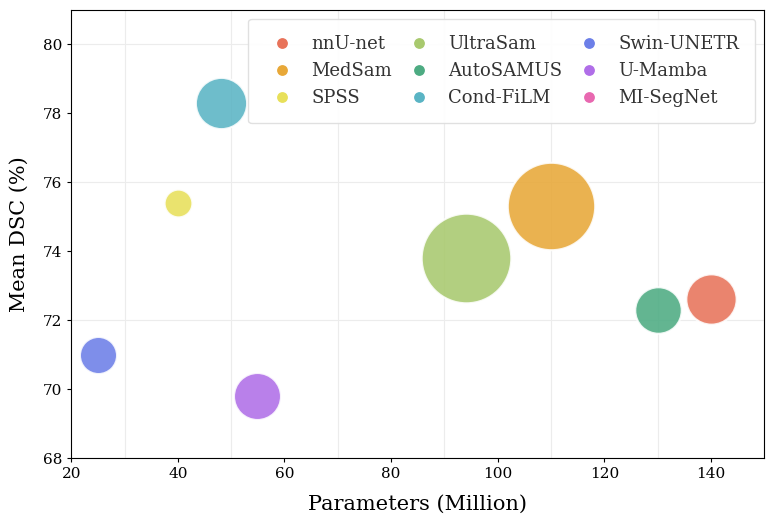

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

models = ["nnU-net", "MedSam", "SPSS", "UltraSam", "AutoSAMUS", "Cond-UNet", "Swin-UNETR", "U-Mamba", "MI-SegNet"]
params = [140, 110, 40, 94, 130, 48, 25.1, 54.8, 68.2]
dice   = [72.61, 75.3, 75.40, 73.81, 72.3, 78.3, 71.0, 69.8, 66.8]
sizes  = [164, 495, 50, 520, 140, 170, 89.1, 143.1 ,60.2] # GFLOPs

palette = [
    "#e8735a",
    "#e8a838",
    "#e8e05a",  # new — yellow
    "#a8c96e",
    "#4dab82",
    "#5ab4c4",
    "#6c7fe8",
    "#b06ee8",  # new — violet
    "#e868b0",  # new — magenta
]

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.spines.top": True,
    "axes.spines.right": True,
    "axes.spines.left": True,
    "axes.spines.bottom": True,
    "axes.edgecolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})

fig, ax = plt.subplots(figsize=(8, 5.5))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

for y in range(52, 85, 4):
    ax.axhline(y, color="#ececec", lw=0.8, zorder=0)
for x in range(30, 175, 20):
    ax.axvline(x, color="#ececec", lw=0.8, zorder=0)

scale = 8
scaled_sizes = [s * scale for s in sizes]

for i, model in enumerate(models):
    ax.scatter(params[i], dice[i], s=scaled_sizes[i],
               color=palette[i], alpha=0.88,
               edgecolors="white", linewidths=1.5, zorder=3)

ax.set_xlim(20, 150)
ax.set_ylim(68, 81)
ax.set_xlabel("Parameters (Million)", labelpad=10, color="black", fontsize=15)
ax.set_ylabel("Mean DSC (%)", labelpad=10, color="black", fontsize=15)
ax.tick_params(colors="black", length=3)

legend_handles = [
    Line2D([0], [0], marker='o', color='w',
           label=model,
           markerfacecolor=palette[i],
           markeredgecolor='white',
           markersize=9, markeredgewidth=1.2)
    for i, model in enumerate(models)
]
leg = ax.legend(
    handles=legend_handles,
    loc="upper right",
    frameon=True,
    framealpha=0.9,
    facecolor="white",
    edgecolor="#ddd",
    fontsize=13,
    labelcolor="#333",
    handletextpad=0.6,
    labelspacing=0.5,
    borderpad=0.9,
    ncols=3,          # ← add this
    columnspacing=.5 # ← tighten column gap if needed
)
plt.tight_layout(pad=1.5)
plt.savefig("/media/raid0/US_FiLMUNet/.tmp/bubble_chart.png",
            dpi=180, bbox_inches="tight", facecolor=fig.get_facecolor())
print("Saved.")

Saved editable table: pareto_models_table_for_editing.csv


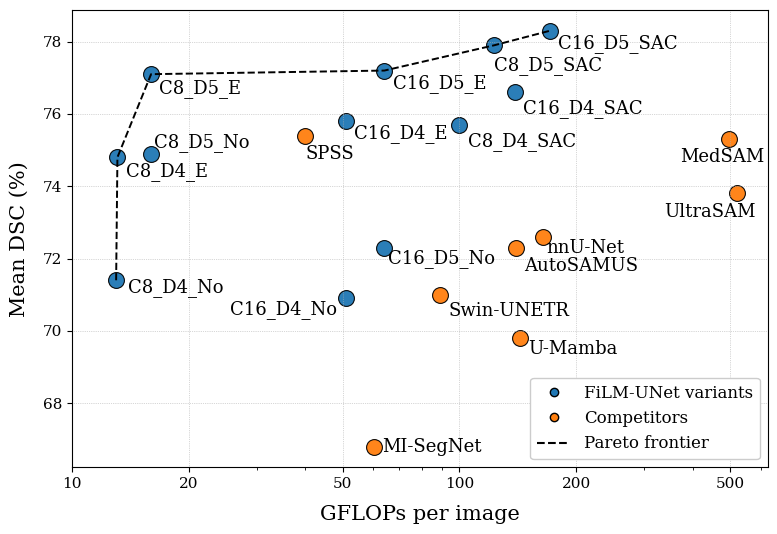

In [115]:
"""
Pareto-style plotting script for MICCAI figure.
Replace the "gflops" values below with your measured/true GFLOPs per image.
Comment out any model lines you don't want to include (use # at line start).
"""

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# -----------------------------
# 1) Define models (editable)
# -----------------------------
# Each entry: ("short_name", "display name", mean_dsc, params_M, gflops_est, category)
# - Replace gflops_est with your real GFLOPs per image (float)
# - To hide a model, comment out its tuple line
models = [
    # FiLM-UNet configs (from Table 1) - keep the names exactly if you want consistent annotations
    ("C8_D4_No",   "FiLM C8 D4 NoCond", 71.4,  1.8,  13.0, "FiLM"),   # <-- replace 5.00 with real GFLOPs
    ("C8_D4_E",    "FiLM C8 D4 E",      74.8,  2.6,  13.1, "FiLM"),
    ("C8_D4_SAC",  "FiLM C8 D4 SAC",    75.7, 18.5, 100.0, "FiLM"),

    ("C16_D4_No",  "FiLM C16 D4 NoCond",70.9,  7.0,  51.0, "FiLM"),
    ("C16_D4_E",   "FiLM C16 D4 E",     75.8,  9.8,  51.0, "FiLM"),
    ("C16_D4_SAC", "FiLM C16 D4 SAC",   76.6, 24.2, 139.0, "FiLM"),

    ("C8_D5_No",   "FiLM C8 D5 NoCond", 74.9,  7.0,  16.0, "FiLM"),
    ("C8_D5_E",    "FiLM C8 D5 E",      77.1,  9.8,  16.0, "FiLM"),
    ("C8_D5_SAC",  "FiLM C8 D5 SAC",    77.9, 26.5, 123.0, "FiLM"),

    ("C16_D5_No",  "FiLM C16 D5 NoCond",72.3, 27.8, 64.0, "FiLM"),
    ("C16_D5_E",   "FiLM C16 D5 E",     77.2, 38.3, 64.0, "FiLM"),
    ("C16_D5_SAC", "FiLM C16 D5 SAC",   78.3, 48.1, 171.0, "FiLM"),

    # Competitors (put your measured GFLOPs, or keep them as placeholders)
    ("nnU-Net",  "nnU-Net", 72.6, 140.0, 164.0, "Competitor"),
    ("Swin-UNETR",  "Swin-UNETR", 71.0, 25.1, 89.1, "Competitor"),
    ("U-Mamba",  "U-Mamba", 69.8, 54.8, 143.11, "Competitor"),
    ("MedSAM",  "MedSAM", 75.3, 110.0, 495.0, "Competitor"),
    ("SPSS",    "SPSS",   75.4, 40.0, 40.0, "Competitor"),
    ("UltraSAM","UltraSAM",73.8, 94.0, 520.0, "Competitor"),
    ("AutoSAMUS",   "AutoSAMUS",  72.3, 130.0, 140.0, "Competitor"),
    ("MI-SegNet",   "MI-SegNet",  66.8, 68.2, 60.2, "Competitor"),
]

# -----------------------------
# 2) Build DataFrame
# -----------------------------
df = pd.DataFrame(models, columns=["short", "display", "mean_dsc", "params_M", "gflops", "category"])

# Optional: if params_M is None for competitors, fill with NaN (already set)
df["params_M"] = df["params_M"].astype(float)
df["gflops"] = df["gflops"].astype(float)
df["mean_dsc"] = df["mean_dsc"].astype(float)

# Save a CSV for easy editing / records
csv_path = "pareto_models_table_for_editing.csv"
df.to_csv(csv_path, index=False)
print(f"Saved editable table: {csv_path}")
# print(df)

# -----------------------------
# 3) Pareto mask (non-dominated: minimize x=gflops, maximize y=mean_dsc)
# -----------------------------
def pareto_mask(x, y):
    """Return boolean mask of pareto-optimal points (True = non-dominated)."""
    n = len(x)
    mask = np.ones(n, dtype=bool)
    for i in range(n):
        for j in range(n):
            # j dominates i if x_j <= x_i and y_j >= y_i and strictly better in at least one
            if (x[j] <= x[i] and y[j] >= y[i]) and (x[j] < x[i] or y[j] > y[i]):
                mask[i] = False
                break
    return mask

# We'll compute Pareto on rows that have valid gflops (non-NaN)
valid_idx = df["gflops"].notna().to_numpy()
x_all = df.loc[valid_idx, "gflops"].to_numpy()
y_all = df.loc[valid_idx, "mean_dsc"].to_numpy()
mask_valid = pareto_mask(x_all, y_all)
pareto_points = df.loc[valid_idx].iloc[mask_valid].copy()
pareto_points = pareto_points.sort_values("gflops")

# -----------------------------
# 4) Publication-style colored plot
# -----------------------------
plt.rcParams.update({"font.size": 12})
fig, ax = plt.subplots(figsize=(8.0, 5.5))

fixed_size = 130

# Professional colors (matplotlib default palette)
film_color = "#1f77b4"      # deep blue
comp_color = "#ff7f0e"      # muted orange



for idx, row in df.iterrows():
    if math.isnan(row["gflops"]):
        continue

    if row["category"] == "FiLM":
        facecolor = film_color
        edgecolor = "black"
    else:
        facecolor = comp_color
        edgecolor = "black"

    ax.scatter(
        row["gflops"],
        row["mean_dsc"],
        s=fixed_size,
        facecolor=facecolor,
        edgecolor=edgecolor,
        linewidth=0.8,
        alpha=0.95,
        marker="o"
    )
    # x_offset = row["gflops"] * 0.02
    # y_offset = -0.3   # move slightly downward
    # Default offsets
    x_mult = 0.02
    y_offset = -0.3

    # Override if custom rule exists
    if row["short"] in custom_offsets:
        x_mult, y_offset = custom_offsets[row["short"]]

    x_offset = row["gflops"] * x_mult
    ax.text(
        row["gflops"] + x_offset,
        row["mean_dsc"] + y_offset,
        row["short"],
        fontsize=13,
        va="center",
        ha="left",
        bbox=dict(
            facecolor="none",
            edgecolor="none",
            alpha=0.7,
            pad=0.5
        )
    )

# Pareto frontier
if len(pareto_points) >= 2:
    ax.plot(
        pareto_points["gflops"],
        pareto_points["mean_dsc"],
        linestyle="--",
        linewidth=1.4,
        color="black",
        label="Pareto frontier"
    )

ax.set_xscale("log")
ax.set_xlabel("GFLOPs per image", labelpad=10, fontsize=15)
ax.set_ylabel("Mean DSC (%)", labelpad=10, fontsize=15)
# ax.set_title("Accuracy–Compute Trade-off (Pareto Frontier)")
custom_ticks = [10, 20, 50, 100, 200, 500]

ax.set_xticks(custom_ticks)
ax.set_xticklabels([str(t) for t in custom_ticks])

ax.grid(True, linestyle=":", linewidth=0.5)

legend_elements = [
    Line2D([0],[0], marker='o', color='w', label='FiLM-UNet variants',
           markerfacecolor=film_color, markeredgecolor='black', markersize=6),
    Line2D([0],[0], marker='o', color='w', label='Competitors',
           markerfacecolor=comp_color, markeredgecolor='black', markersize=6),
    Line2D([0],[0], linestyle='--', color='black', label='Pareto frontier')
]

ax.legend(handles=legend_elements, loc="lower right", framealpha=1)

plt.tight_layout()
plt.savefig("/media/raid0/US_FiLMUNet/.tmp/pareto_plot.png", dpi=300, bbox_inches="tight")
plt.savefig("/media/raid0/US_FiLMUNet/.tmp/pareto_plot.svg", bbox_inches="tight")
plt.show()




In [114]:
custom_offsets = {
    "C8_D5_No":   (0.02, 0.3),     # move UP
    "C16_D4_No":  (-0.5, -0.3),     # move UP
    "C8_D4_No":  (0.07, -0.2),     # move UP
    "C8_D4_E":  (0.05, -0.4),     # move UP
    "C8_D5_E":  (0.05, -0.4),     # move UP
    "C8_D4_SAC":  (0.05, -0.45),     # move UP
    "C16_D4_SAC":  (0.05, -0.45),     # move UP
    "C16_D4_SAC":  (0.05, -0.45),     # move UP
    "C16_D5_SAC":  (0.05, -0.35),     # move UP
    "C16_D5_E":  (0.05, -0.35),     # move UP
    "C16_D4_E":  (0.05, -0.35),     # move UP
    "C8_D5_SAC":  (0.0, -0.55),     # move UP
    "MedSAM":     (-0.25, -0.5),   # move LEFT
    "UltraSAM":   (-0.35, -0.5),   # move LEFT
    "AutoSAMUS":   (0.05, -0.5),      # move LEFT
    "U-Mamba":   (0.05, -0.3),      # move LEFT
    "Swin-UNETR":   (0.05, -0.45),      # move LEFT
    "SPSS":   (0, -0.5),      # move LEFT
    "MI-SegNet":   (0.05, 0),      # move LEFT
    "nnU-net":   (0.1, 0),      # move LEFT
    # "nnUNet":   (0.1, 0.3),      # move LEFT
}

In [ ]:
from safetensors.torch import load_file
from nets.unet_attn import UNet2DAttn
from safetensors.torch import load_file
model = UNet2DAttn(
    in_channels=3,
    num_classes=1,
    n_organs=10,
    size=16,
    depth=5,
    attn_start=0,      # Start attention from first level
    use_attn=True,     # Enable attention
    img_size=512,      # Input image size
    patch_size=8,     # 16×16 patches → 256 patches total
    emb_dim=768,       # Embedding dimension
    n_heads=8,          # Number of attention heads,
    # n_transformer_layers = 12,
    distill = 0,
    use_dwt=False,
    wavelet='haar',
    # dwt_bands=['HH'],
    use_shape = False,
    shape_res=64,
    # distill_unet=True
)
model.cuda()
print(sum([p.numel() for n, p in model.named_parameters() if 'distill_model' not in n]))
# state_dict = load_file("./loggings/6c4b0a465d57/checkpoint-8000/model.safetensors")
state_dict = load_file("/media/raid0/US_FiLMUNet/loggings/dd9c669e4884/checkpoint-8400/model.safetensors")
state_dict = {k: v for k, v in state_dict.items() if 'distill' not in k } #remove distiller, is useless
load_results = model.load_state_dict(state_dict, strict=True)
print(load_results)

In [ ]:
from segment_anything import sam_model_registry
from copy import deepcopy
from nets.segm_net import UNet2DFiLM, MedSAM, MedSAMPrompt
from safetensors.torch import load_file
sam_model = sam_model_registry["vit_b"](checkpoint=MEDSAM_BASE_WEIGHTS)

model = MedSAM(
    image_encoder=deepcopy(sam_model.image_encoder),
    mask_decoder=deepcopy(sam_model.mask_decoder),
    prompt_encoder=deepcopy(sam_model.prompt_encoder),
    predict_bboxes=True,
    freeze_image_encoder=0,
)
state_dict = load_file(
    "/media/raid0/US_FiLMUNet/loggings/54b9c61bc00c/checkpoint-7600/model.safetensors"
)
model.load_state_dict(state_dict)
load_result = model.load_state_dict(state_dict)
print(load_result)
model.eval()
model = model.cuda()

In [ ]:
to_pil_image((data["pixel_values"] - data["pixel_values"].min()) / (data["pixel_values"].max() -data["pixel_values"].min()))

In [ ]:
from utils.utils import class_to_organ_dict
from PIL import Image

device = torch.device("cuda:3")
model.to(device)
for i in range(len(dataset)):
    data = dataset.__getitem__(i)
    organ = class_to_organ_dict[data['organ_id']]
    oid = int(data["organ_id"])
    organ_id = torch.tensor([oid], dtype=torch.long, device=device)  # shape (1,)
    # pil_im = to_pil_image((data["pixel_values"] - data["pixel_values"].min()) / (data["pixel_values"].max() -data["pixel_values"].min()))
    model.eval()
    with torch.no_grad():
        out = model(
            pixel_values=data["pixel_values"].unsqueeze(0).to(device),
            masks=data["masks"].unsqueeze(0).to(device),
            organ_id=organ_id,
            pixel_values_medsam=data["pixel_values_medsam"].unsqueeze(0).to(device),
        )
        
    # # out['loss']
    pil_im = to_pil_image((torch.sigmoid(out["logits"]) > 0.7).to(torch.float))
    pil_im.save(f"/media/raid0/US_FiLMUNet/.tmp/medsam_masks/{organ}_{i}.png")
    # break



In [ ]:
model.forward(
            pixel_values=data["pixel_values"].unsqueeze(0).to(device),
            masks=data["masks"].unsqueeze(0).to(device),
            organ_id=torch.Tensor(data['organ_id']).long().to(device),
            pixel_values_medsam=data["pixel_values_medsam"].unsqueeze(0).to(device)
        )

In [ ]:
pil_im.save("/media/raid0/US_FiLMUNet/.tmp/unet2dattn_masks/")

In [13]:
from PIL import Image
from torchvision.transforms.functional import to_pil_image, pil_to_tensor
from pathlib import Path
im = Image.open("/media/raid0/US_FiLMUNet/.tmp/nnunet_pred/inferTs_0/private_Breast_benign_1.png")
to_pil_image(pil_to_tensor(im).float())

for p in Path('/media/raid0/US_FiLMUNet/.tmp/nnunet_pred/inferTs_0').rglob('*.png'):
    im = Image.open(str(p))
    im = to_pil_image(pil_to_tensor(im).float())
    im.save(f"/media/raid0/US_FiLMUNet/.tmp/nnunet_pred/{p.name}")
    # break

In [11]:
p

PosixPath('/media/raid0/US_FiLMUNet/.tmp/nnunet_pred/inferTs_0/private_Breast_malignant_86.png')